# Model Fitting for SIRSEI Malaria Model

This notebook demonstrates fitting the SIRSEI (Susceptible-Infectious-Recovered for Humans, Susceptible-Exposed-Infectious for Mosquitoes) malaria model to real epidemiological data from Manaus.

## Overview

The fitting process uses:
- **Real climate data**: Temperature and precipitation from `climate_api_data_2016_2024.csv`
- **Real case data**: Active malaria cases from `cumulative_manaus_cases_2016_2023.csv`
- **State variable**: `active_total` fitted to `Ih` (Infectious Humans)

## Parameters

### Optimizable Parameters:
- `T_prime`, `pME`, `pML`, `pMP`, `c1`, `c2`, `b1`, `b2`, `A`, `B`, `C`

### Fixed Parameters:
- `BE`, `tauE`, `tauP`, `D1`, `RL`, `mu_H`, `gamma`, `DD`, `Tmin`, `M`, `N`

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from epimodels.continuous.models import SIRSEIData
from epimodels.fitting import (
    Dataset,
    ParameterSpec,
    ModelFitter,
    ScipyOptimizer,
    SumOfSquaredErrors,
)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 2. Load Real Data

In [2]:
DATA_PATH = './data/'

climate_df = pd.read_csv(f'{DATA_PATH}climate_api_data_2016_2024.csv')
cases_df = pd.read_csv(f'{DATA_PATH}cumulative_manaus_cases_2016_2023.csv')

climate_df['date'] = pd.to_datetime(climate_df['date'])
cases_df['date'] = pd.to_datetime(cases_df['date'])

merged_df = pd.merge(cases_df, climate_df, on='date', how='inner')
print(f"Merged data: {len(merged_df)} rows")
print(f"Date range: {merged_df['date'].min()} to {merged_df['date'].max()}")

Merged data: 3042 rows
Date range: 2016-01-01 00:00:00 to 2024-04-29 00:00:00


## 3. Prepare Climate Data for Model

In [3]:
merged_df['day_number'] = (merged_df['date'] - merged_df['date'].min()).dt.days

day_numbers = merged_df['day_number'].values
temperatures = merged_df['temp_med'].values
precipitations = merged_df['precip_med'].values

temp_interp = interp1d(day_numbers, temperatures, kind='linear',
                       bounds_error=False, fill_value='extrapolate')
precip_interp = interp1d(day_numbers, precipitations, kind='linear',
                          bounds_error=False, fill_value='extrapolate')

print(f"Temperature range: {temperatures.min():.2f}°C to {temperatures.max():.2f}°C")
print(f"Precipitation range: {precipitations.min():.2f}mm to {precipitations.max():.2f}mm")

Temperature range: 23.12°C to 32.55°C
Precipitation range: 0.00mm to 71.17mm


## 4. Initialize SIRSEIData Model

In [4]:
model = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)
print(f"Model type: {model.model_type}")
print(f"State variables: {list(model.state_variables.keys())}")

Model type: SIR-SEI-Data
State variables: ['Sh', 'Ih', 'Rh', 'Sv', 'Ev', 'Iv']


## 5. Prepare Data for Fitting

In [5]:
N = 9586
M = 3000

# Initial conditions from data
initial_Ih = merged_df['active_total'].iloc[0]
initial_Rh = merged_df['active_total'].iloc[0] * 0.3
initial_Sh = N - initial_Ih - initial_Rh

initial_Sv = M * 0.99
initial_Ev = M * 0.009
initial_Iv = M * 0.001

inits = [initial_Sh, initial_Ih, initial_Rh, initial_Sv, initial_Ev, initial_Iv]
print(f"Initial conditions: Sh={initial_Sh:.0f}, Ih={initial_Ih:.0f}, Rh={initial_Rh:.0f}")

Initial conditions: Sh=5010, Ih=3520, Rh=1056


In [6]:
times = merged_df['day_number'].values
observed_prevalence = merged_df['active_total'].values.astype(float)
observed_incidence = merged_df['new_cases'].fillna(0).values.astype(float)

print(f"Time points: {len(times)}")
print(f"Prevalence range: {observed_prevalence.min():.0f} to {observed_prevalence.max():.0f}")
print(f"Incidence range: {observed_incidence.min():.0f} to {observed_incidence.max():.0f}")

Time points: 3042
Prevalence range: 0 to 4897
Incidence range: 0 to 124


## 6. Define Parameters

In [7]:
# Use only 3 key transmission parameters for fast fitting
param_specs = [
    ParameterSpec(name='b1', bounds=(0.1, 0.9), initial=0.4),
    ParameterSpec(name='b2', bounds=(0.3, 0.9), initial=0.7),
    ParameterSpec(name='gamma', bounds=(0.001, 0.05), initial=0.008),
]

fixed_params = {
    'BE': 200,
    'tauE': 1,
    'tauP': 1,
    'D1': 32.5,
    'RL': 32.26,
    'mu_H': 0.00004,
    'DD': 105,
    'Tmin': 14.5,
    'T_prime': 21.6,
    'pME': 0.9,
    'pML': 0.25,
    'pMP': 0.75,
    'c1': 0.0554,
    'c2': 0.1737,
    'A': 32.5,
    'B': 15.0,
    'C': 48.78,
    'N': N,
    'M': M,
}

print(f"Fitting: {[p.name for p in param_specs]}")
print(f"Fixed: {len(fixed_params)} parameters")

Fitting: ['b1', 'b2', 'gamma']
Fixed: 19 parameters


## 7. Create Dataset

In [8]:
model_for_fitting = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)

dataset = Dataset(model_for_fitting)
dataset.register(
    name='prevalence',
    values=observed_prevalence,
    times=times,
    state_variable='Ih',
    time_unit='days',
)

validation = dataset.validate(N + M)
print(f"Dataset valid: {validation.is_valid}")
if not validation.is_valid:
    print(f"Errors: {validation.errors}")

Dataset valid: True


## 8. Run Model Fitting

In [9]:
# Use fast local optimizer L-BFGS-B
optimizer = ScipyOptimizer(
    method='L-BFGS-B',
    max_iterations=100,
)

fitter = ModelFitter(
    model=model_for_fitting,
    dataset=dataset,
    parameters_to_fit=param_specs,
    total_population=N + M,
    fixed_params=fixed_params,
    optimizer=optimizer,
    loss_fn=SumOfSquaredErrors(),
)

print("Running optimization (this should be fast)...")
result = fitter.fit()

print(f"\n=== Optimization Results ===")
print(f"Convergence: {result.convergence}")
print(f"Evaluations: {result.n_evaluations}")
print(f"Final loss: {result.best_loss:.2f}")

Running optimization (this should be fast)...

=== Optimization Results ===
Convergence: False
Evaluations: 380
Final loss: 2786931018.50


## 9. Results

In [10]:
final_params = {**fixed_params, **result.best_params}

fitted_model = SIRSEIData(temp_func=temp_interp, precip_func=precip_interp)
fitted_model(
    inits=inits,
    trange=[times.min(), times.max()],
    totpop=N + M,
    params=final_params,
)

fitted_times = fitted_model.traces['time']
fitted_Ih = fitted_model.traces['Ih']

# Calculate incidence from model
T_vals = temp_interp(fitted_times)
a_vals = np.maximum((T_vals - final_params['T_prime']) / final_params['D1'], 0)
fitted_incidence = a_vals * final_params['b2'] * (fitted_model.traces['Iv'] / N) * fitted_model.traces['Sh']

print(f"Model Ih range: {fitted_Ih.min():.0f} to {fitted_Ih.max():.0f}")
print(f"Model incidence range: {fitted_incidence.min():.0f} to {fitted_incidence.max():.0f}")

Model Ih range: 961 to 4968
Model incidence range: 0 to 13


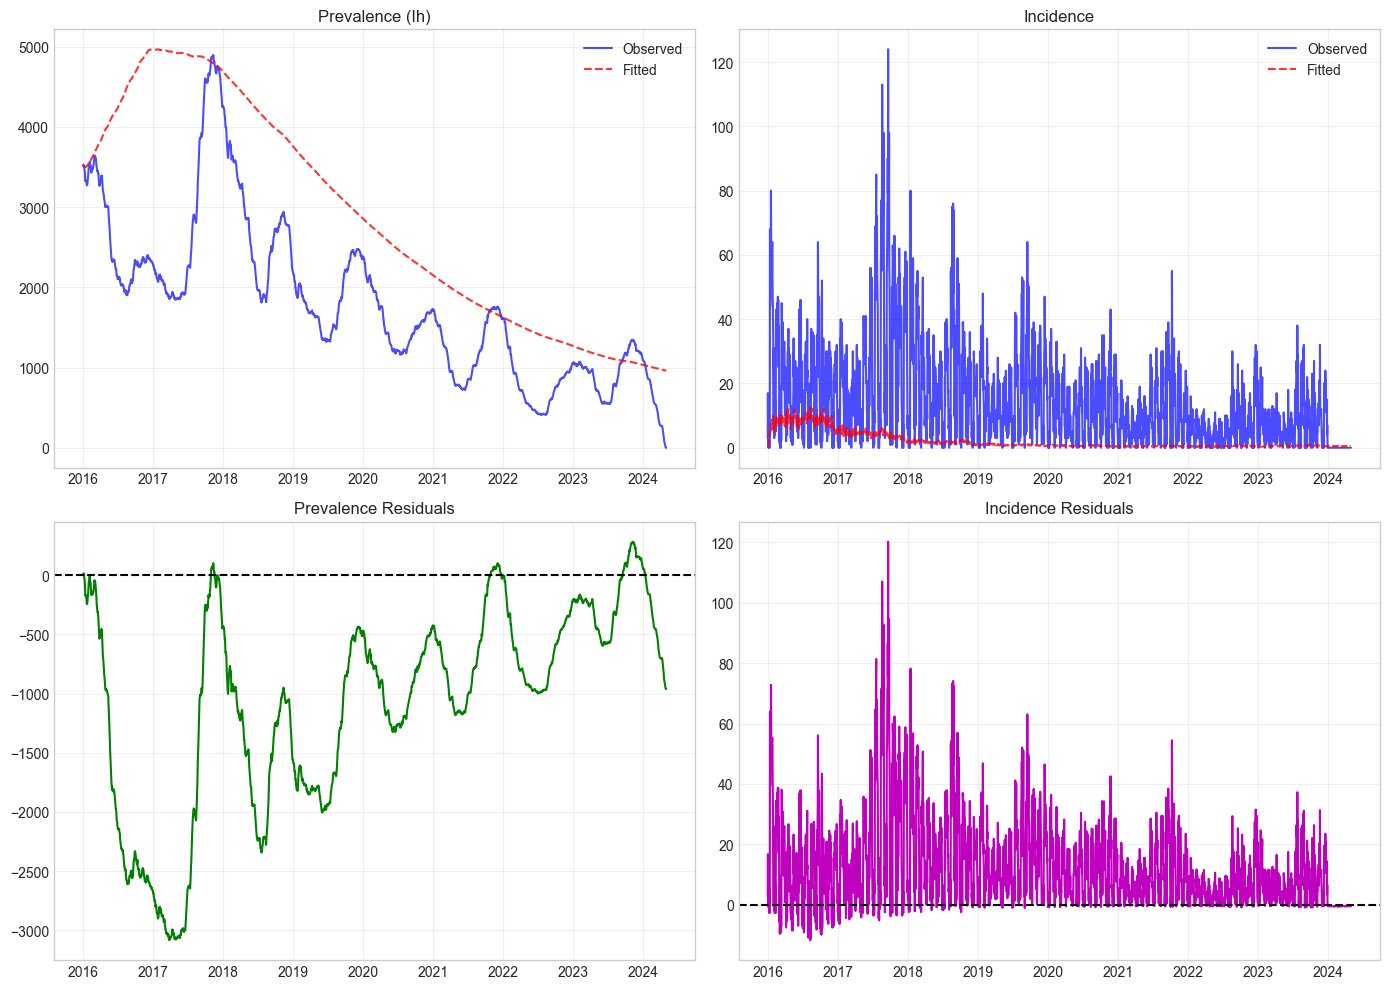


Fit Quality:
  Prevalence RMSE: 1365.30
  Incidence RMSE: 19.09


In [11]:
dates = merged_df['date'].values

# Interpolate to observed time points
fitted_Ih_interp = np.interp(times, fitted_times, fitted_Ih)
fitted_incidence_interp = np.interp(times, fitted_times, fitted_incidence)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Prevalence
axes[0, 0].plot(dates, observed_prevalence, 'b-', alpha=0.7, label='Observed')
axes[0, 0].plot(dates, fitted_Ih_interp, 'r--', alpha=0.8, label='Fitted')
axes[0, 0].set_title('Prevalence (Ih)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Incidence
axes[0, 1].plot(dates, observed_incidence, 'b-', alpha=0.7, label='Observed')
axes[0, 1].plot(dates, fitted_incidence_interp, 'r--', alpha=0.8, label='Fitted')
axes[0, 1].set_title('Incidence')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Prevalence residuals
residuals_prev = observed_prevalence - fitted_Ih_interp
axes[1, 0].plot(dates, residuals_prev, 'g-')
axes[1, 0].axhline(y=0, color='k', linestyle='--')
axes[1, 0].set_title('Prevalence Residuals')
axes[1, 0].grid(True, alpha=0.3)

# Incidence residuals
residuals_inc = observed_incidence - fitted_incidence_interp
axes[1, 1].plot(dates, residuals_inc, 'm-')
axes[1, 1].axhline(y=0, color='k', linestyle='--')
axes[1, 1].set_title('Incidence Residuals')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rmse_prev = np.sqrt(np.mean(residuals_prev**2))
rmse_inc = np.sqrt(np.mean(residuals_inc**2))

print(f"\nFit Quality:")
print(f"  Prevalence RMSE: {rmse_prev:.2f}")
print(f"  Incidence RMSE: {rmse_inc:.2f}")

## 10. R0 Analysis

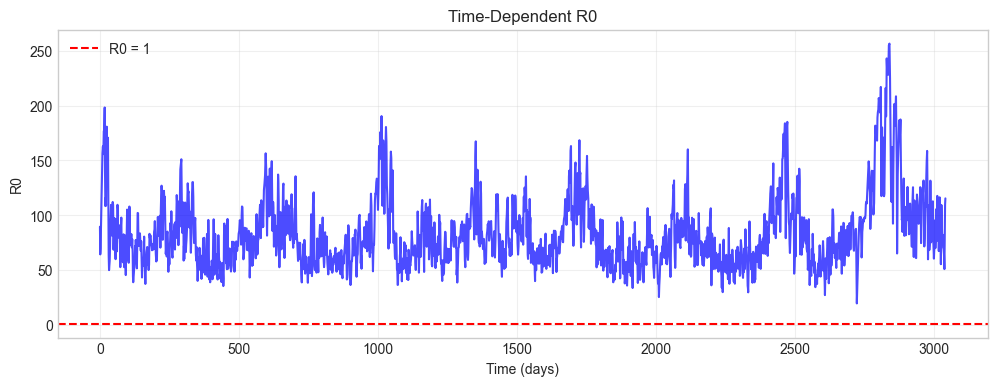

R0 range: 19.42 to 256.76


In [12]:
# Calculate R0 over time
r0_values = [fitted_model.R0_t(t) for t in fitted_times]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fitted_times, r0_values, 'b-', alpha=0.7)
ax.axhline(y=1, color='r', linestyle='--', label='R0 = 1')
ax.set_xlabel('Time (days)')
ax.set_ylabel('R0')
ax.set_title('Time-Dependent R0')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"R0 range: {min(r0_values):.2f} to {max(r0_values):.2f}")